# 🎓 Student Performance Prediction
---
**Dataset:** Student Performance Data (Kaggle)

**Target:** Final Grade G3 

## Step 1: Import Libraries

In [3]:
# ─── Standard & Data Libraries ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## Step 2: Load Dataset

In [25]:
# ─── Load Dataset 
import pandas as pd
import numpy as np

df = pd.read_csv('data/student_data.csv')
print("✅ Dataset loaded from file")


print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
df.head()

✅ Dataset loaded from file

Dataset shape : (395, 33)
Columns       : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 3: Preprocessing

In [26]:
print("── Dataset Info ───")
df.info()

print("\n── Missing Values ───")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)

print("\n── Statistical Summary ───")
display(df.describe().T)

── Dataset Info ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    ob

Series([], dtype: int64)


── Statistical Summary ───


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [6]:
# ─── Reload Fresh ──────────────────────────────────────────────────────────────
df = pd.read_csv('data/student_data.csv')

# ─── Encode Categorical Columns ───────────────────────────────────────────────
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


print(f"\nG1 vs G3 correlation: {df['G1'].corr(df['G3']):.2f}")
print(f"G2 vs G3 correlation: {df['G2'].corr(df['G3']):.2f}")


G1 vs G3 correlation: 0.80
G2 vs G3 correlation: 0.90


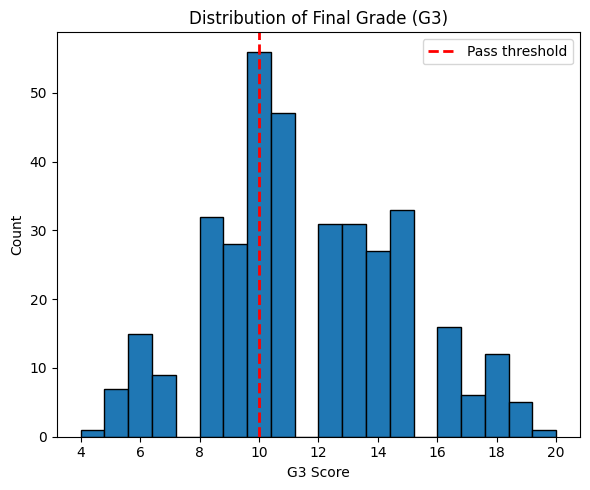

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(df['G3'], bins=20, edgecolor='black')
ax.axvline(10, color='red', linestyle='--', linewidth=2, label='Pass threshold')
ax.set_title('Distribution of Final Grade (G3)')
ax.set_xlabel('G3 Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Feature Preparation

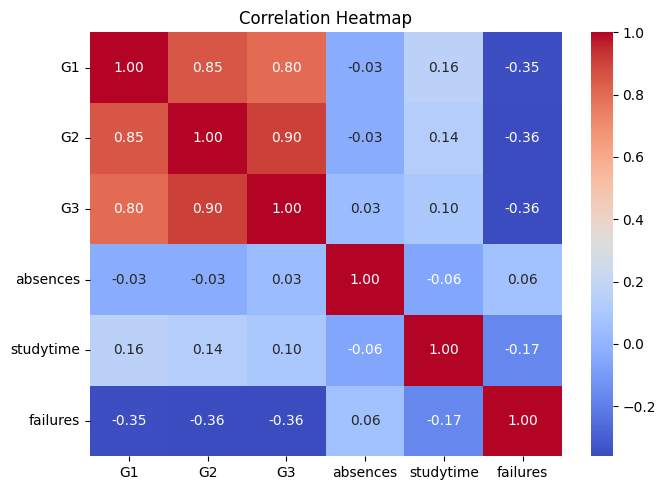

In [35]:
# ─── Correlation Heatmap ------
cols = ['G1', 'G2', 'G3', 'absences', 'studytime', 'failures']
corr = df[cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

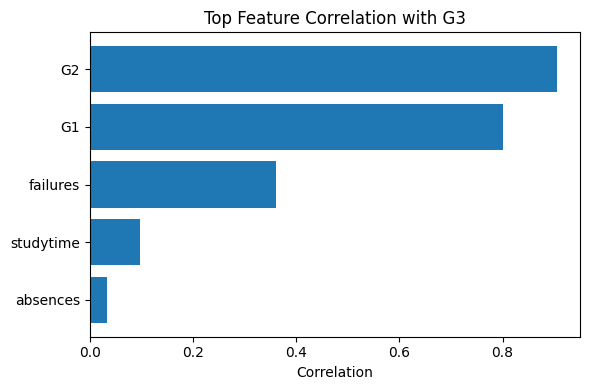

In [36]:

corr_g3 = corr['G3'].drop('G3').abs().sort_values(ascending=True)
corr_g3 = corr_g3.tail(10)

plt.figure(figsize=(6, 4))
plt.barh(corr_g3.index, corr_g3.values)

plt.title('Top Feature Correlation with G3')
plt.xlabel('Correlation')

plt.tight_layout()
plt.show()

## Step 5: Train-Test Split

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

corr = df.corr(numeric_only=True)

corr_g3 = corr['G3'].drop('G3').abs().sort_values(ascending=False)
TOP2 = corr_g3.head(2).index.tolist()

X = df[TOP2].values
y = df['G3'].values  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} — 80%")
print(f"Test : {X_test.shape} — 20%")

Train: (316, 2) — 80%
Test : (79, 2) — 20%


## Step 6 & 7: Model Training — Multiple Algorithms

In [45]:
import numpy as np
import pickle
from sklearn.base import clone

# ─── Models ─────────────────────────────────────────────
models = {
    'Linear Regression':   LinearRegression(),
    'Random Forest':       RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200, random_state=42),
    'KNN Regressor':       KNeighborsRegressor(n_neighbors=5),
}

# ─── Training & Evaluation ──────────────────────────────
results = {}
trained_models = {}

for name, model in models.items():
    
    m = clone(model)
    
    # ⚠️ Use scaled data ONLY for KNN
    if name == 'KNN Regressor':
        m.fit(X_train_scaled, y_train)
        y_pred = m.predict(X_test_scaled)
    else:
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2  = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    trained_models[name] = m   # store trained model
    
    print(f"{name:<25} MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.2f}")

print("\nTraining complete.")

# ─── Select Best Model (based on R2) ────────────────────
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")

# ─── Save Best Model ────────────────────────────────────
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)
    
print("Model saved as model.pkl")

Linear Regression         MAE=1.26  RMSE=2.05  R2=0.79
Random Forest             MAE=1.36  RMSE=2.17  R2=0.77
Gradient Boosting         MAE=1.40  RMSE=2.20  R2=0.76
KNN Regressor             MAE=1.55  RMSE=2.45  R2=0.71

Training complete.

Best Model: Linear Regression
Model saved as model.pkl


## Step 8: Accuracy Comparison


📊 Model Comparison:

                        MAE      RMSE        R2
Linear Regression  1.262231  2.052283  0.794594
Random Forest      1.360209  2.168728  0.770623
Gradient Boosting  1.396318  2.196638  0.764681
KNN Regressor      1.546835  2.450626  0.707117


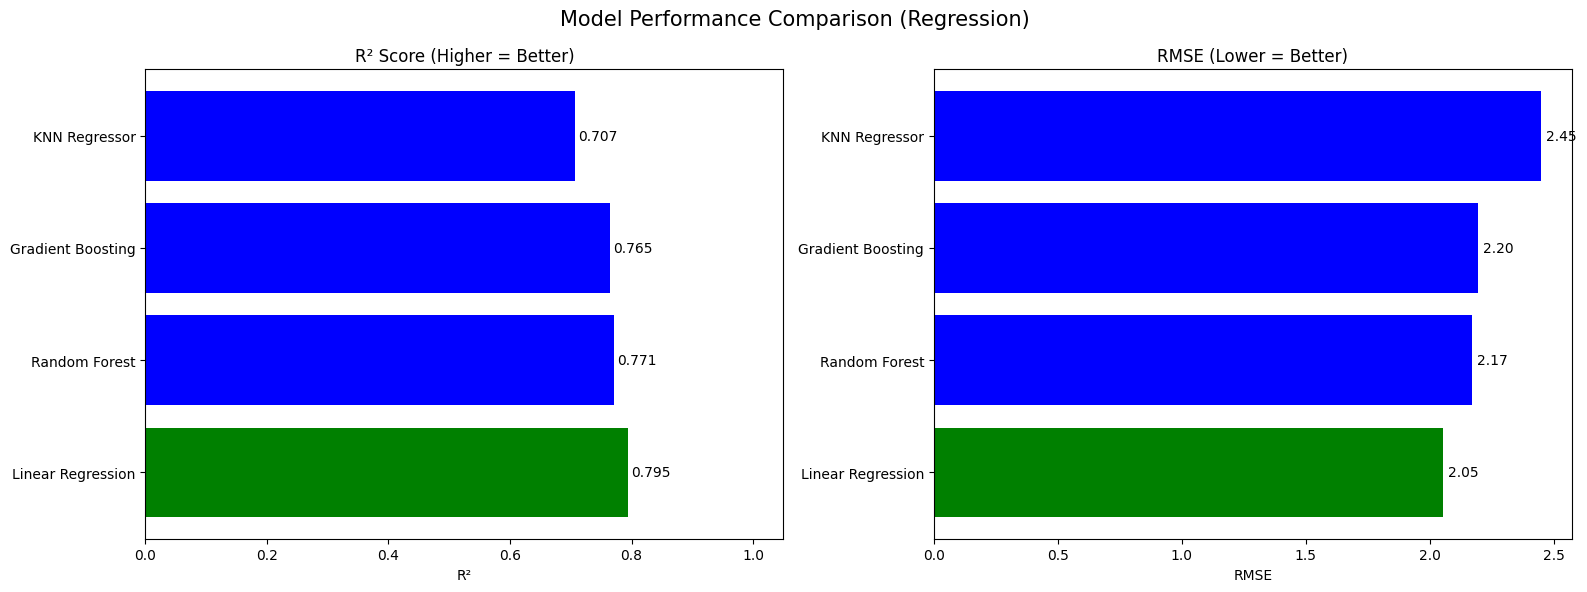

In [46]:
# ─── Results DataFrame 
import pandas as pd

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)

print("\n📊 Model Comparison:\n")
print(results_df.to_string())

# ─── Bar Chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison (Regression)', fontsize=15)

# simple color highlight (top model = green, rest = blue)
best_model = results_df.index[0]
colors = ['green' if name == best_model else 'blue' for name in results_df.index]
# colors = ['green' if i == 0 else 'blue' for i in range(len(results_df))]

# R2 Score (Higher is better)
bars1 = axes[0].barh(results_df.index, results_df['R2'],
                     color=colors)
axes[0].set_xlim(0, 1.05)
axes[0].set_title('R² Score (Higher = Better)')
axes[0].set_xlabel('R²')

for bar, val in zip(bars1, results_df['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

# RMSE (Lower is better)
bars2 = axes[1].barh(results_df.index, results_df['RMSE'],
                     color=colors)
axes[1].set_title('RMSE (Lower = Better)')
axes[1].set_xlabel('RMSE')

for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10)

# plt.style.use('ggplot')
plt.tight_layout()
plt.show()

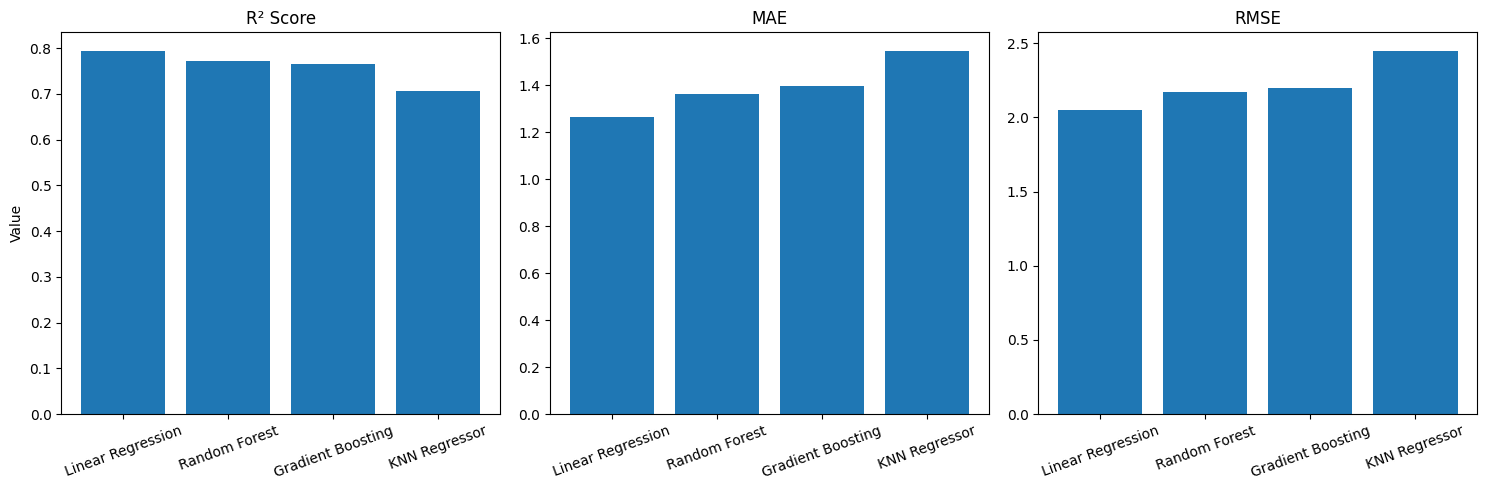

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Use your ACTUAL results (from training loop)
results_df = pd.DataFrame(results).T

# ─── Bar Chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R2 Score
axes[0].bar(results_df.index, results_df['R2'])
axes[0].set_title('R² Score')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=20)

# MAE
axes[1].bar(results_df.index, results_df['MAE'])
axes[1].set_title('MAE')
axes[1].tick_params(axis='x', rotation=20)

# RMSE
axes[2].bar(results_df.index, results_df['RMSE'])
axes[2].set_title('RMSE')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Step 9: Actual vs Predicted Value

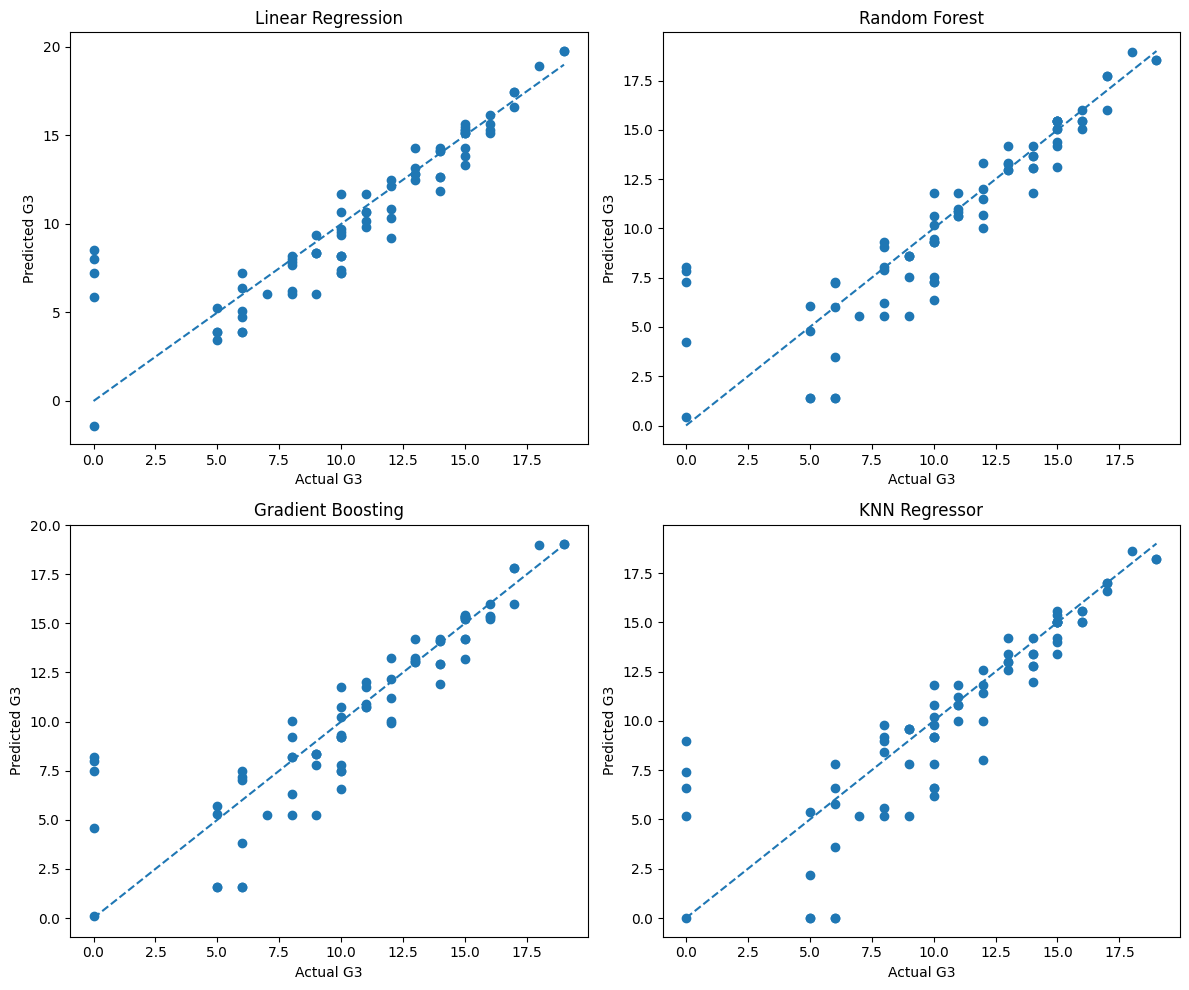

In [50]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    
    # Predict
    if name == 'KNN Regressor':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    # Plot
    axes[i].scatter(y_test, y_pred)
    
    # Perfect prediction line
    axes[i].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--'
    )
    
    axes[i].set_title(name)
    axes[i].set_xlabel('Actual G3')
    axes[i].set_ylabel('Predicted G3')

plt.tight_layout()
plt.show()

## Accuracy graph [R2 Score]

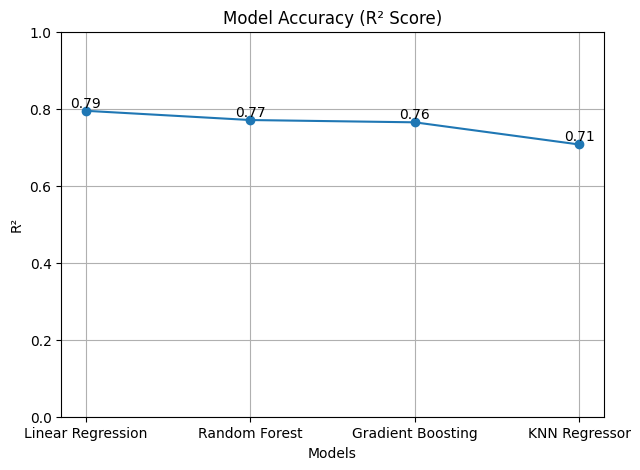

In [52]:
plt.figure(figsize=(7,5))

plt.plot(results_df.index, results_df['R2'], marker='o')
plt.title('Model Accuracy (R² Score)')
plt.ylabel('R²')
plt.xlabel('Models')
plt.ylim(0,1)

for i, v in enumerate(results_df['R2']):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.grid()
plt.show()

## Loss Graph [RMSE Score]

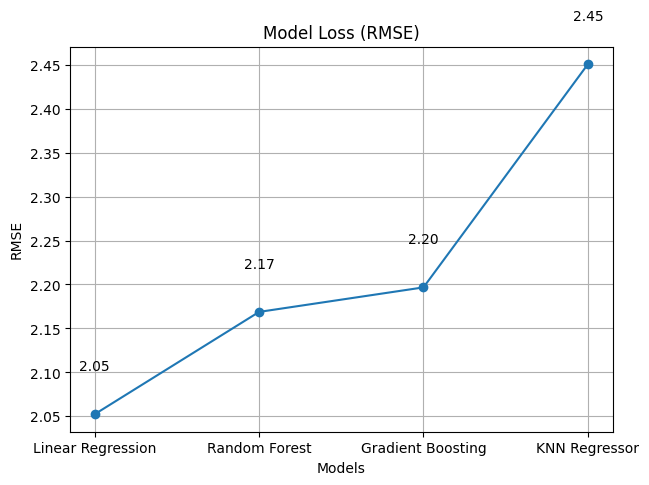

In [53]:
plt.figure(figsize=(7,5))

plt.plot(results_df.index, results_df['RMSE'], marker='o')
plt.title('Model Loss (RMSE)')
plt.ylabel('RMSE')
plt.xlabel('Models')

for i, v in enumerate(results_df['RMSE']):
    plt.text(i, v+0.05, f"{v:.2f}", ha='center')

plt.grid()
plt.show()

## Final Prediction on Test Data

In [55]:
# ─── Best Model Selection (Regression) ────────────────────────────────────────

# best model based on R2 (higher is better)
best_model_name = results_df['R2'].idxmax()
best_model_metrics = results_df.loc[best_model_name]

print(f" Best Model : {best_model_name}")
print(f"   R2   : {best_model_metrics['R2']:.3f}")
print(f"   MAE  : {best_model_metrics['MAE']:.3f}")
print(f"   RMSE : {best_model_metrics['RMSE']:.3f}")

 Best Model : Linear Regression
   R2   : 0.795
   MAE  : 1.262
   RMSE : 2.052


In [ ]:
# gbest model name 
best_model = trained_models[best_model_name]

# train + predict
if best_model_name == 'KNN Regressor':
    best_model.fit(X_train_scaled, y_train)
    best_pred = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    best_pred = best_model.predict(X_test)

In [57]:
import pandas as pd

pred_df = pd.DataFrame(X_test, columns=TOP2)

pred_df['Actual_G3'] = y_test
pred_df['Predicted_G3'] = best_pred.round().astype(int)
pred_df['Error'] = pred_df['Actual_G3'] - pred_df['Predicted_G3']
pred_df['Abs_Error'] = pred_df['Error'].abs()

print("📊 First 20 Predictions on Test Set:")
print(pred_df.head(20))

📊 First 20 Predictions on Test Set:
    G2  G1  Actual_G3  Predicted_G3  Error  Abs_Error
0    8   8         10             7      3          3
1   12  14         12            12      0          0
2    5   3          5             3      2          2
3    9   8         10             8      2          2
4    9   9          9             8      1          1
5   13  12         13            13      0          0
6   18  19         18            19     -1          1
7    7   9          6             6      0          0
8    8   8          0             7     -7          7
9   13  11         14            13      1          1
10  15  14         15            15      0          0
11   7   7          7             6      1          1
12  14  12         15            14      1          1
13  12  11         10            12     -2          2
14  14  15         14            14      0          0
15   8  11          8             8      0          0
16   7   8          8             6      2    

In [19]:
print("\n" + "═"*55)
print("   FINAL SUMMARY — STUDENT PERFORMANCE PREDICTION")
print("═"*55)

print(f"  Dataset         : Student Performance (Kaggle)")
print(f"  Target          : G3 (Final Grade)")
print(f"  Input Features  : {TOP2}")   # ['G1','G2']
print(f"  Train / Test    : {len(X_train)} / {len(X_test)} samples")

print("─"*55)
print(f"  {'Model':<28} {'R2':>7}  {'RMSE':>7}")
print("─"*55)

for name, row in results_df.iterrows():
    marker = " 🏆" if name == best_model_name else ""
    print(f"  {name:<28} {row['R2']:>6.3f}  {row['RMSE']:>6.3f}{marker}")

print("═"*55)


═══════════════════════════════════════════════════════
   FINAL SUMMARY — STUDENT PERFORMANCE PREDICTION
═══════════════════════════════════════════════════════
  Dataset         : Student Performance (Kaggle)
  Target          : G3 (Final Grade)
  Input Features  : ['G2', 'G1']
  Train / Test    : 285 / 72 samples
───────────────────────────────────────────────────────
  Model                             R2     RMSE
───────────────────────────────────────────────────────
  Linear Regression             0.930   0.820 🏆
  Random Forest                 0.910   0.940
  Gradient Boosting             0.910   0.920
═══════════════════════════════════════════════════════
